In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
students = pd.read_csv('students.csv')
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')
nov = pd.read_csv('reg-month1.csv')
dec = pd.read_csv('reg-month2.csv')
courses = pd.read_csv('courses.csv')

In [22]:
nov.shape

(25, 2)

In [23]:
dec.shape

(28, 2)

In [42]:
 nov_dec = pd.concat([nov,dec],ignore_index=True)

In [25]:
nov_dec.shape

(53, 2)

In [26]:
nov_dec

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [28]:
# multi indexing in DataFrame
nov_dec = pd.concat([nov,dec],keys=['nov','dec'])

In [31]:
nov_dec.loc[('dec',5)]

student_id    7
course_id     7
Name: (dec, 5), dtype: int64

In [32]:
nov_dec.loc[('nov',10)]

student_id    19
course_id      4
Name: (nov, 10), dtype: int64

In [40]:
# joining two data side by side
nov_dec = pd.concat([nov,dec],axis=0)

### Merge

In [35]:
#inner join 
new_data =  students.merge(nov_dec,how='inner',on='student_id')

In [36]:
new_data

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [43]:
# find the total revenue generated
nov_dec

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [60]:
 data = nov_dec.merge(courses,how='inner',on='course_id')

In [62]:
total_revenue  = data['price'].sum()

In [63]:
total_revenue

np.int64(154247)

In [64]:
data

,student_id,course_id,course_name,price
0,23,1,python,2499
1,15,5,tableau,2499
2,18,6,power bi,1899
3,23,4,machine learning,9999
4,16,9,plotly,699
5,18,1,python,2499
6,1,1,python,2499
7,7,8,pandas,1099
8,22,3,data analysis,4999
9,15,1,python,2499


In [70]:
# find the month by month revenue
revenue1 = nov.merge(courses,how='inner',on='course_id')['price'].sum()
revenue2 = dec.merge(courses,how='inner',on='course_id')['price'].sum()
total_revenue = revenue1 + revenue2

In [77]:
nov_dec

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [78]:
data = nov_dec.merge(students,how='inner',on='student_id')

In [81]:
data

,student_id,course_id,name,partner
0,23,1,Chhavi Lachman,18
1,15,5,Preet Sha,16
2,18,6,Fardeen Mahabir,13
3,23,4,Chhavi Lachman,18
4,16,9,Elias Dodiya,25
5,18,1,Fardeen Mahabir,13
6,1,1,Kailash Harjo,23
7,7,8,Tarun Thaker,9
8,22,3,Yash Sethi,21
9,15,1,Preet Sha,16


In [82]:
data2 = data.merge(courses,how='inner',on='course_id')

In [84]:
data2.head(2)

,student_id,course_id,name,partner,course_name,price
0,23,1,Chhavi Lachman,18,python,2499
1,15,5,Preet Sha,16,tableau,2499


In [87]:
# plot a bar graph courses vs revenue
gp = data2.groupby('course_name')

In [92]:
coursea_revenue = gp['price'].sum().sort_values(ascending=False)

In [93]:
coursea_revenue

course_name
machine learning    39996
data analysis       24995
python              19992
tableau             17493
pyspark             14994
power bi            11394
ms sxcel             7995
sql                  6998
pandas               3297
plotly               2796
Name: price, dtype: int64

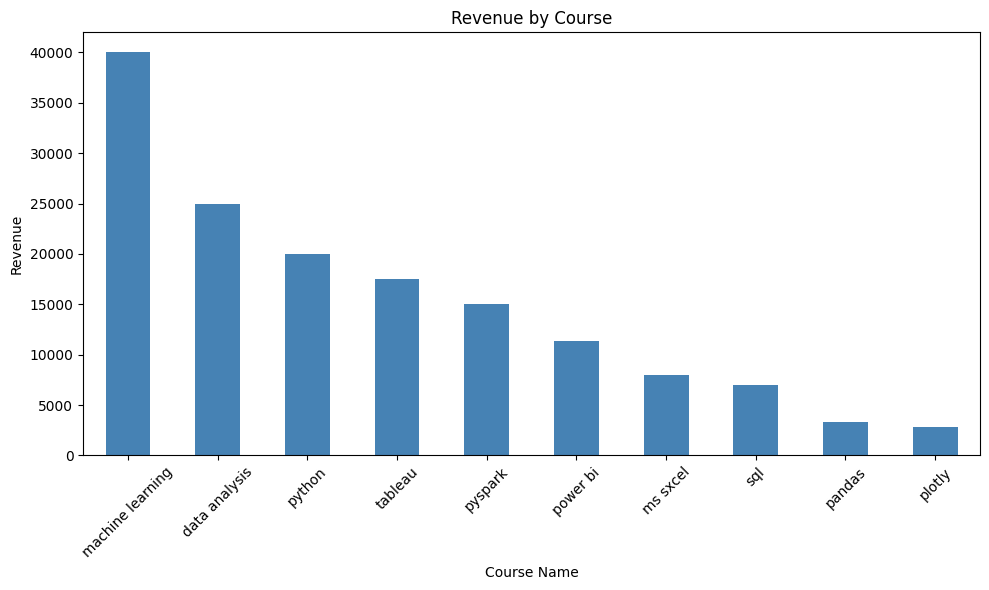

In [94]:
plt.figure(figsize=(10,6))
coursea_revenue.plot(kind='bar', color='steelblue')
plt.title('Revenue by Course')
plt.xlabel('Course Name')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [100]:
# find the name of the students who enrolled in both the months
data1 = courses.merge(nov,how='inner',on='course_id')

In [101]:
data2 = courses.merge(dec,how='inner',on='course_id')

In [102]:
data1.shape

(25, 4)

In [104]:
data2.shape

(28, 4)

In [105]:
data3 = data2.merge(data1,how='inner',on='course_id')

In [106]:
data3.shape

(66, 7)

In [ ]:
data3.head(1)